# Learning to stabilize a linear system with Robustness

We follow Part 1 example (example/control/Part_1_stabilize_linear_system) and demonstrate how to learn a robust stabilizing controller for a double integrator system using [Differentiable predictive control (DPC) method](https://www.sciencedirect.com/science/article/pii/S0959152422000981) and introduce a Lipschitz estimation method [EClipsE](https://proceedings.neurips.cc/paper_files/paper/2024/hash/1419d8554191a65ea4f2d8e1057973e4-Abstract-Conference.html) to charaterize the robustness of the learned controller. 

**Differentiable Predictive Control method**:  
The DPC is a model-based policy optimization algorithm, that exploits the differentiability of a wide class of model representations for dynamical systems, including differential equations, state-space models, or various neural network architectures. In DPC, we construct a differentiable closed-loop system composed of neural control policy and system dynamics model that is to be optimized using parametric control objectives as intrinsic reward signals evaluated over a sampled distribution of the problem parameters.

<img src="./figs/DPC_simple_method.png" width="600">  


**ECLipsE**:  
The Lipschitz constant plays a crucial role in certifying the robustness of neural networks to input perturbations. ***eclipse-nn*** package provides strict, accurate, efficient, and scalable $\ell_2$-norm Lipschitz estimates on FNN. One can check examples/tutorial/part_4_Lipschitz_estimator for the demonstration on the package.

## NeuroMANCER , eclipse-nn and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [1]:
!pip install neuromancer

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

In [2]:
!pip install eclipse-nn==0.1.4

In [3]:
import torch
import torch.nn as nn
from neuromancer.system import Node, System
from neuromancer.modules import blocks
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.plot import pltCL, pltPhase


In [4]:
from eclipse_nn.LipConstEstimator import LipConstEstimator

In [5]:
import random
import numpy as np

# Python built-in random
random.seed(42)

# NumPy
np.random.seed(42)

# PyTorch (CPU and GPU)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)   # if using multi-GPU

# Make cuDNN deterministic (slower, but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Node and System classes

The Node class is a simple wrapper for any callable pytorch function or nn.Module which provides names for the inputs and outputs to be used in composition of a potentially cyclic computational graph.  

In [6]:
# Double integrator parameters
nx = 2
nu = 1
A = torch.tensor([[1.2, 1.0],
                  [0.0, 1.0]])
B = torch.tensor([[1.0],
                  [0.5]])

# linear state space model
xnext = lambda x, u: x @ A.T + u @ B.T    
double_integrator = Node(xnext, ['X', 'U'], ['X'], name='integrator')

# We will define the node for the neural control policy in the Optimization Problem Section for different training and wrap the closed-loop system node.

# Training dataset generation

For a training dataset we randomly sample points away from the origin of the 2D space the system operates in. 

In [7]:
# Training dataset generation
train_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='train')  # Split conditions into train and dev
dev_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='dev')
train_loader = torch.utils.data.DataLoader(train_data, batch_size=3333,
                                           collate_fn=train_data.collate_fn, shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=3333,
                                         collate_fn=dev_data.collate_fn, shuffle=False)

# Optimization problem with a system rollout of 2 time steps

We want to learn a controller that stabilizes the double integrator system. In other words we would like a control policy that pushes the system to stay at the origin. Here we offer three ways of training.  
1. Standard training. Same as example/control/Part_1_stabilize_linear_system.
2. Add penaly on the Jacobian of policy u=NN(x).
3. Add penaly on the Jacobian of closed-loop dynamic f(x,u) = f(x,NN(x)).

Method 2 and 3 are expected to yield more robustness controllers and smoother trajectories.

## Standard Training

In [8]:
# neural control policy
mlp = blocks.MLP(nx, nu, bias=True,
                 linear_map=torch.nn.Linear,
                 nonlin=torch.nn.ReLU,
                 hsizes=[20, 20, 20, 20])
policy = Node(mlp, ['X'], ['U'], name='policy')

# closed loop system definition
cl_system = System([policy, double_integrator])
# cl_system.show()

In [9]:
# Define optimization problem
u = variable('U')
x = variable('X')
action_loss = 0.0001 * (u == 0.)^2  # control penalty
regulation_loss = 10. * (x == 0.)^2  # target position
loss = PenaltyLoss([action_loss, regulation_loss], [])
problem = Problem([cl_system], loss)
optimizer = torch.optim.AdamW(policy.parameters(), lr=0.001)

In [10]:
trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=500,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)

# Train model with prediction horizon of 2
cl_system.nsteps = 2
best_model = trainer.train()

C:\Users\22384\OneDrive - purdue.edu\Purdue\Research\ECLipsE_package_application\neuromancer\src\neuromancer\constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([3333, 2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)
C:\Users\22384\OneDrive - purdue.edu\Purdue\Research\ECLipsE_package_application\neuromancer\src\neuromancer\constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([3333, 3, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0  train_loss: 202.42628479003906
epoch: 1  train_loss: 201.84446716308594
epoch: 2  train_loss: 201.25
epoch: 3  train_loss: 200.6475067138672
epoch: 4  train_loss: 200.03172302246094
epoch: 5  train_loss: 199.40264892578125
epoch: 6  train_loss: 198.76254272460938
epoch: 7  train_loss: 198.11053466796875
epoch: 8  train_loss: 197.44590759277344
epoch: 9  train_loss: 196.77001953125
epoch: 10  train_loss: 196.0867156982422
epoch: 11  train_loss: 195.40872192382812
epoch: 12  train_loss: 194.7261962890625
epoch: 13  train_loss: 194.01625061035156
epoch: 14  train_loss: 193.2728271484375
epoch: 15  train_loss: 192.4952392578125
epoch: 16  train_loss: 191.68118286132812
epoch: 17  train_loss: 190.82876586914062
epoch: 18  train_loss: 189.9380645751953
epoch: 19  train_loss: 189.00718688964844
epoch: 20  train_loss: 188.03286743164062
epoch: 21  train_loss: 187.0134735107422
epoch: 22  train_loss: 185.9462890625
epoch: 23  train_loss: 184.82933044433594
epoch: 24  train_loss: 183.6

## Apply Curriculum Training and add regularization on the Jacobian of policy u=NN(x)

In [11]:
import copy
from torch import func

def make_jac_node(policy_node):
    # Capture the specific model instance you are training
    model = policy_node.callable
    
    def _jac_calculator(X):
        # Helper for single sample
        def single_sample_fn(x_single):
            # unsqueeze(0) makes it [1, nx] for the linear layer
            # view(-1) forces output to be [nu] (vector), NOT scalar
            return model(x_single.unsqueeze(0)).view(-1)

        # Vectorized Jacobian
        batch_jac = func.vmap(func.jacrev(single_sample_fn))(X)
        
        # Norm over (nu, nx) -> [Batch, 1]
        return torch.linalg.norm(batch_jac, ord='fro', dim=(-2, -1)).unsqueeze(-1)

    return Node(_jac_calculator, ['X'], ['Jfro'], name='jac_fro')



# reuse the trained NN
policy_reg = copy.deepcopy(policy)


# Create the Node with the optimized function
jac_fro = make_jac_node(policy_reg)

# closed loop system definition (add the jac_fro node)
cl_system_reg = System([policy_reg, double_integrator, jac_fro])

In [12]:
# variables
u = variable('U')
x = variable('X')
j = variable('Jfro')   # from the Jacobian-Fro node

action_loss     =  0.0001 * (u == 0.)^2       
regulation_loss = 10. * (x == 0.)^2     
jac_loss    = 0.1 * (j == 0.)^2 

loss_reg = PenaltyLoss([action_loss, regulation_loss,jac_loss], [])
problem_reg = Problem([cl_system_reg], loss_reg)

optimizer = torch.optim.AdamW(policy_reg.parameters(), lr=0.005)

In [13]:
trainer_reg = Trainer(
    problem_reg,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=200,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)


# Train model with prediction horizon of 2
cl_system_reg.nsteps = 2
best_model_reg = trainer_reg.train()

epoch: 0  train_loss: 40.6180534362793
epoch: 1  train_loss: 43.02133560180664
epoch: 2  train_loss: 40.752777099609375
epoch: 3  train_loss: 41.40171432495117
epoch: 4  train_loss: 42.035823822021484
epoch: 5  train_loss: 41.27503967285156
epoch: 6  train_loss: 40.67487716674805
epoch: 7  train_loss: 40.766971588134766
epoch: 8  train_loss: 41.17424011230469
epoch: 9  train_loss: 41.32158279418945
epoch: 10  train_loss: 41.09956741333008
epoch: 11  train_loss: 40.77112579345703
epoch: 12  train_loss: 40.63334274291992
epoch: 13  train_loss: 40.7569580078125
epoch: 14  train_loss: 40.94389724731445
epoch: 15  train_loss: 40.97682571411133
epoch: 16  train_loss: 40.8380012512207
epoch: 17  train_loss: 40.67622375488281
epoch: 18  train_loss: 40.626380920410156
epoch: 19  train_loss: 40.70969772338867
epoch: 20  train_loss: 40.80422592163086
epoch: 21  train_loss: 40.80208206176758
epoch: 22  train_loss: 40.71742630004883
epoch: 23  train_loss: 40.632259368896484
epoch: 24  train_loss: 4

In [14]:
'''
import torch
import torch.nn as nn
from neuromancer.system import Node, System
from neuromancer.modules import blocks
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer

# Double integrator parameters
nx = 2
nu = 1
A = torch.tensor([[1.2, 1.0],
                  [0.0, 1.0]])
B = torch.tensor([[1.0],
                  [0.5]])

# Linear state space model
xnext = lambda x, u: x @ A.T + u @ B.T    
double_integrator = Node(xnext, ['X', 'U'], ['X'], name='integrator')

# Training dataset generation
# Note: Using shape [Batch, 1, nx] so system handles time-slicing correctly
train_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='train')  
dev_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='dev')

train_loader = torch.utils.data.DataLoader(train_data, batch_size=3333,
                                         collate_fn=train_data.collate_fn, shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=3333,
                                       collate_fn=dev_data.collate_fn, shuffle=False)

# Neural control policy
mlp_reg = blocks.MLP(nx, nu, bias=True,
                 linear_map=torch.nn.Linear,
                 nonlin=torch.nn.ReLU,
                 hsizes=[20, 20, 20, 20])
policy_reg = Node(mlp_reg, ['X'], ['U'], name='policy')

# --- DEFINING THE TRIVIAL LIPSCHITZ NODE ---
def _lip_bound_node(X):
    """
    Calculates Product of Spectral Norms: Pi ||W_i||_2
    """
    Lip_Tr = 1.0
    # Iterate through layers to find weights
    for m in mlp_reg.modules():
        if isinstance(m, torch.nn.Linear):
            # Spectral norm (largest singular value)
            # We take [0] because svdvals returns values in descending order
            sigma_max = torch.linalg.svdvals(m.weight)[0]
            Lip_Tr = Lip_Tr * sigma_max
    
    # X comes in as [Batch, nx].
    # We expand the scalar Lipschitz bound to [Batch, 1]
    # so it matches the shape requirements of the System rollout
    return Lip_Tr.expand(X.shape[0], 1)

# We wrap it in a Node taking 'X' as input to get batch size
lip_node = Node(_lip_bound_node, ['X'], ['Lip_Bound'], name='lip_node')

# Closed loop system definition (Adding lip_node exactly like you added jac_fro)
cl_system_reg = System([policy_reg, double_integrator, lip_node])

# --- VARIABLES & LOSS ---
u = variable('U')
x = variable('X')
l = variable('Lip_Bound')  # Variable for our new node output

action_loss     = 0.0001 * (u == 0.)^2        
regulation_loss = 10. * (x == 0.)^2     

# Penalize square of the product: (Pi ||W||)^2
# We use (l == 0.)^2 which minimizes l towards 0
lip_loss        = 5.0 * (l == 0.)^2 

loss_reg = PenaltyLoss([action_loss, regulation_loss, lip_loss], [])
problem_reg = Problem([cl_system_reg], loss_reg)

optimizer = torch.optim.AdamW(policy_reg.parameters(), lr=0.003)

trainer_reg = Trainer(
    problem_reg,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=500,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)

# Train model with prediction horizon of 2
cl_system_reg.nsteps = 2
best_model_reg = trainer_reg.train()
'''

'\nimport torch\nimport torch.nn as nn\nfrom neuromancer.system import Node, System\nfrom neuromancer.modules import blocks\nfrom neuromancer.dataset import DictDataset\nfrom neuromancer.constraint import variable\nfrom neuromancer.loss import PenaltyLoss\nfrom neuromancer.problem import Problem\nfrom neuromancer.trainer import Trainer\n\n# Double integrator parameters\nnx = 2\nnu = 1\nA = torch.tensor([[1.2, 1.0],\n                  [0.0, 1.0]])\nB = torch.tensor([[1.0],\n                  [0.5]])\n\n# Linear state space model\nxnext = lambda x, u: x @ A.T + u @ B.T    \ndouble_integrator = Node(xnext, [\'X\', \'U\'], [\'X\'], name=\'integrator\')\n\n# Training dataset generation\n# Note: Using shape [Batch, 1, nx] so system handles time-slicing correctly\ntrain_data = DictDataset({\'X\': 3.*torch.randn(3333, 1, nx)}, name=\'train\')  \ndev_data = DictDataset({\'X\': 3.*torch.randn(3333, 1, nx)}, name=\'dev\')\n\ntrain_loader = torch.utils.data.DataLoader(train_data, batch_size=3333,\

## Train with regularization on the Jacobian of  closed-loop dynamic f(x,u) = f(x,NN(x))

In [15]:
def make_jac_cl_node(policy_node, A, B):
    """
    Factory to create an optimized Node for ||A + B * Jac_pi(x)||_F.
    
    Args:
        policy_node: Neuromancer Node containing the policy
        A, B: System matrices (torch.Tensor)
    """
    model = policy_node.callable
    
    # Ensure A and B are tensors
    if not isinstance(A, torch.Tensor): A = torch.tensor(A)
    if not isinstance(B, torch.Tensor): B = torch.tensor(B)

    def _jac_cl_calculator(X):
        """
        Input: X [Batch, nx]
        Output: Jcl_fro [Batch, 1]
        """
        # 1. Define single-sample function for the Policy Jacobian
        def single_sample_fn(x_single):
            # Input: [nx]
            # Model expects [1, nx], Output [1, nu] -> Flatten to [nu]
            return model(x_single.unsqueeze(0)).view(-1)

        # 2. Vectorize the Jacobian computation
        # func.jacrev: Computes J_pi for one sample -> [nu, nx]
        # func.vmap: Stacks them over batch -> [Batch, nu, nx]
        batch_j_pi = func.vmap(func.jacrev(single_sample_fn))(X)
        
        # 3. Compute Closed-Loop Jacobian: J_cl = A + B @ J_pi
        # B: [nx, nu], J_pi: [Batch, nu, nx]
        # torch.matmul automatically broadcasts B to [1, nx, nu]
        # Result: [Batch, nx, nx]
        term_B_Jpi = torch.matmul(B.to(X.device), batch_j_pi)
        
        J_cl = A.to(X.device) + term_B_Jpi

        # 4. Compute Frobenius Norm
        # Reduce over the last two dimensions (nx, nx) -> [Batch]
        norm_val = torch.linalg.norm(J_cl, ord='fro', dim=(-2, -1))
        
        return norm_val.unsqueeze(-1) # [Batch, 1]

    return Node(_jac_cl_calculator, ['X'], ['Jcl_fro'], name='jac_cl')


# reuse the trained NN
policy_reg_cl = copy.deepcopy(policy)


# Create the node 
jac_cl_node = make_jac_cl_node(policy_reg_cl, A, B)

# closed loop system definition (add the jac_fro node)
cl_system_reg_cl = System([policy_reg_cl, double_integrator, jac_cl_node])

In [16]:
# variables
u = variable('U')
x = variable('X')
jcl = variable('Jcl_fro')   # from the Jacobian-Fro node

action_loss     =  0.0001 * (u == 0.)^2       
regulation_loss = 10. * (x == 0.)^2     
jac_cl_loss    = 0.1 * (jcl == 0.)^2 

loss_reg_cl = PenaltyLoss([action_loss, regulation_loss,jac_cl_loss], [])
problem_reg_cl = Problem([cl_system_reg_cl], loss_reg_cl)


# optimizer = torch.optim.AdamW(policy_reg_cl.parameters(), lr=0.003)
optimizer = torch.optim.AdamW(policy_reg_cl.parameters(), lr=0.003)

trainer_reg_cl = Trainer(
    problem_reg_cl,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=200,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)


# Train model with prediction horizon of 2
cl_system_reg_cl.nsteps = 2
best_model_reg_cl = trainer_reg_cl.train()

epoch: 0  train_loss: 40.434757232666016
epoch: 1  train_loss: 40.48573303222656
epoch: 2  train_loss: 41.20869827270508
epoch: 3  train_loss: 40.46328353881836
epoch: 4  train_loss: 41.0341911315918
epoch: 5  train_loss: 40.809173583984375
epoch: 6  train_loss: 40.45029830932617
epoch: 7  train_loss: 40.58307647705078
epoch: 8  train_loss: 40.77069091796875
epoch: 9  train_loss: 40.6135368347168
epoch: 10  train_loss: 40.452171325683594
epoch: 11  train_loss: 40.51280212402344
epoch: 12  train_loss: 40.6280517578125
epoch: 13  train_loss: 40.60441207885742
epoch: 14  train_loss: 40.48683547973633
epoch: 15  train_loss: 40.4338493347168
epoch: 16  train_loss: 40.4944953918457
epoch: 17  train_loss: 40.54832458496094
epoch: 18  train_loss: 40.50674057006836
epoch: 19  train_loss: 40.44411087036133
epoch: 20  train_loss: 40.44841766357422
epoch: 21  train_loss: 40.49380874633789
epoch: 22  train_loss: 40.502769470214844
epoch: 23  train_loss: 40.46394729614258
epoch: 24  train_loss: 40.4

# Evaluate best model on a system rollout 

## Standard Training

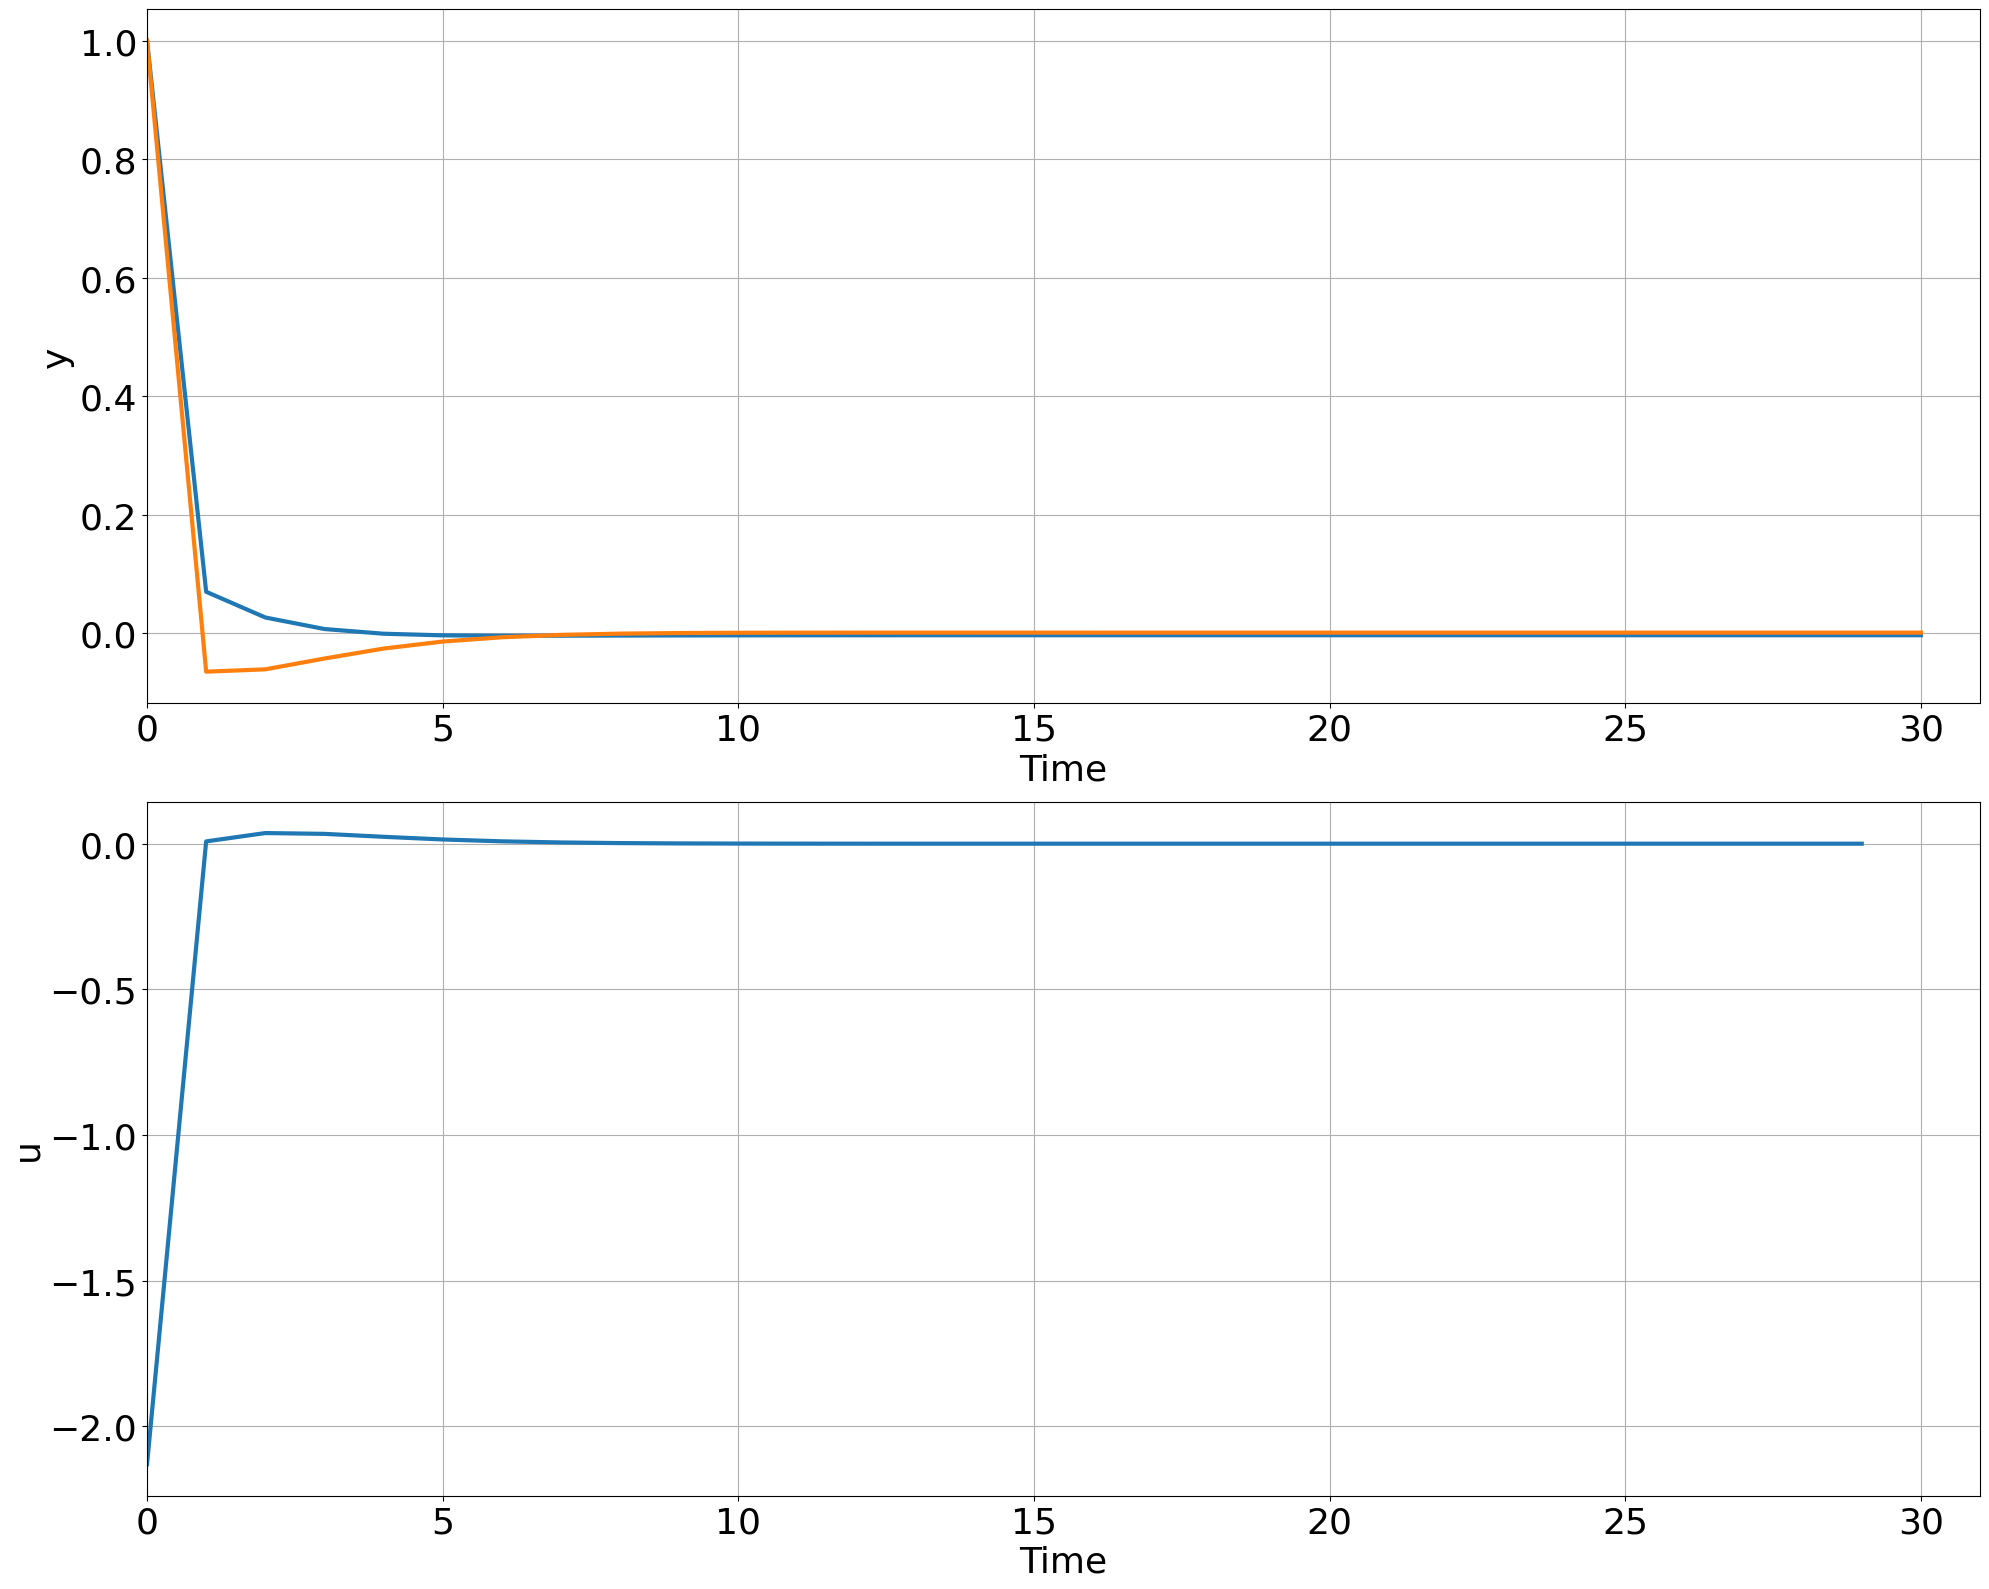

<Figure size 640x480 with 0 Axes>

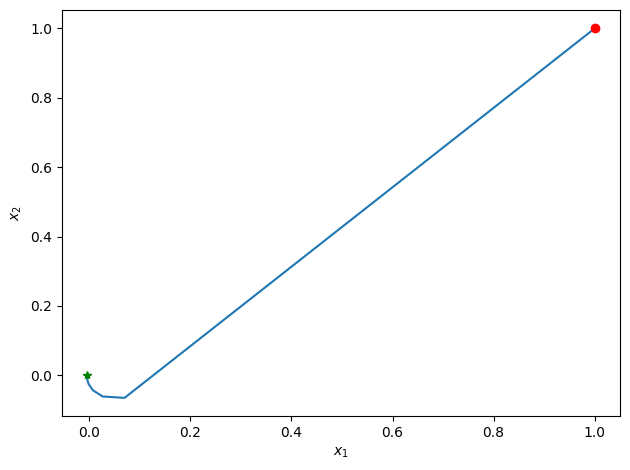

<Figure size 640x480 with 0 Axes>

In [17]:
# Test best model with prediction horizon of 50
problem.load_state_dict(best_model)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system.nsteps = nsteps
trajectories = cl_system(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')

## With Regularization on the Jacobian of policy u=NN(x)

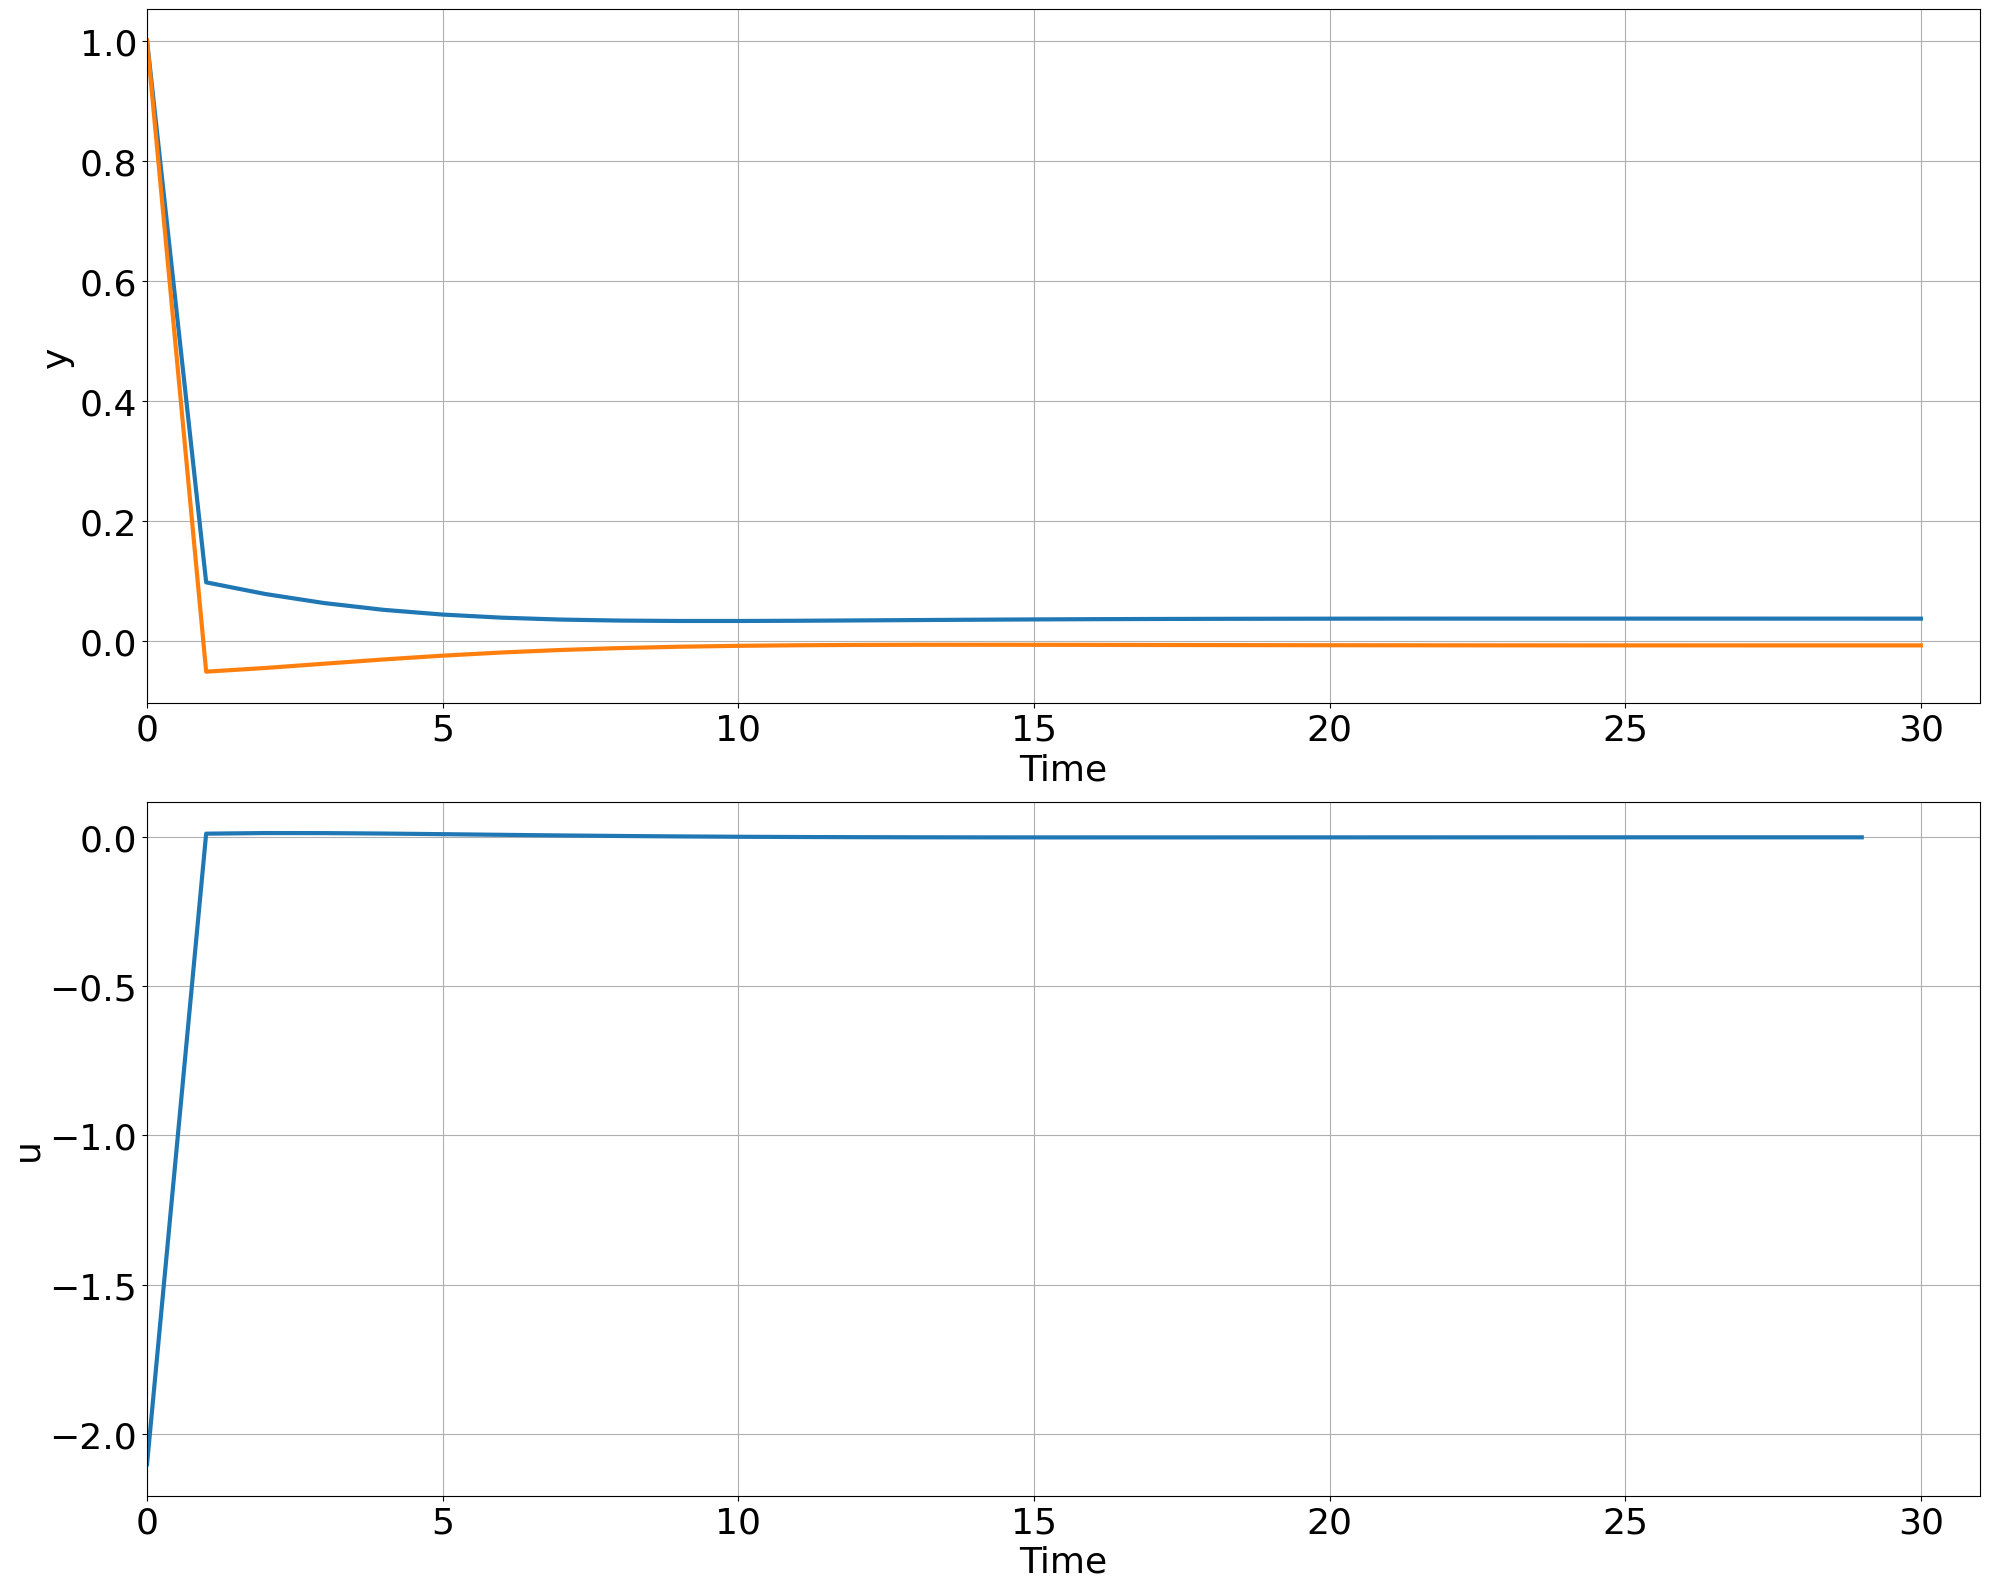

<Figure size 640x480 with 0 Axes>

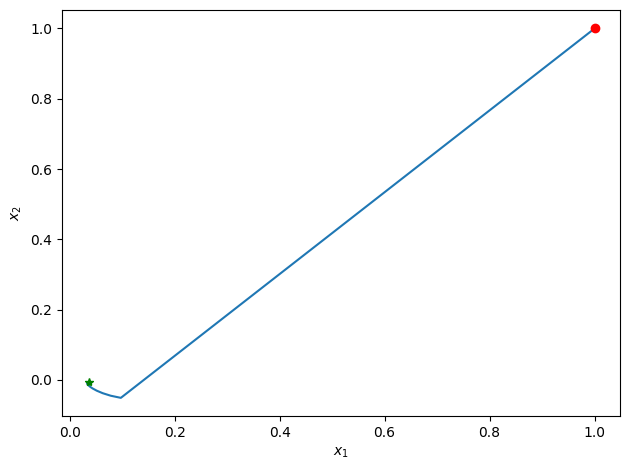

<Figure size 640x480 with 0 Axes>

In [18]:
# Test best model with prediction horizon of 50
problem_reg.load_state_dict(best_model_reg)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system_reg.nsteps = nsteps
trajectories = cl_system_reg(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')

## With Regularization on the Jacobian of  closed-loop dynamic f(x,u) = f(x,NN(x)).

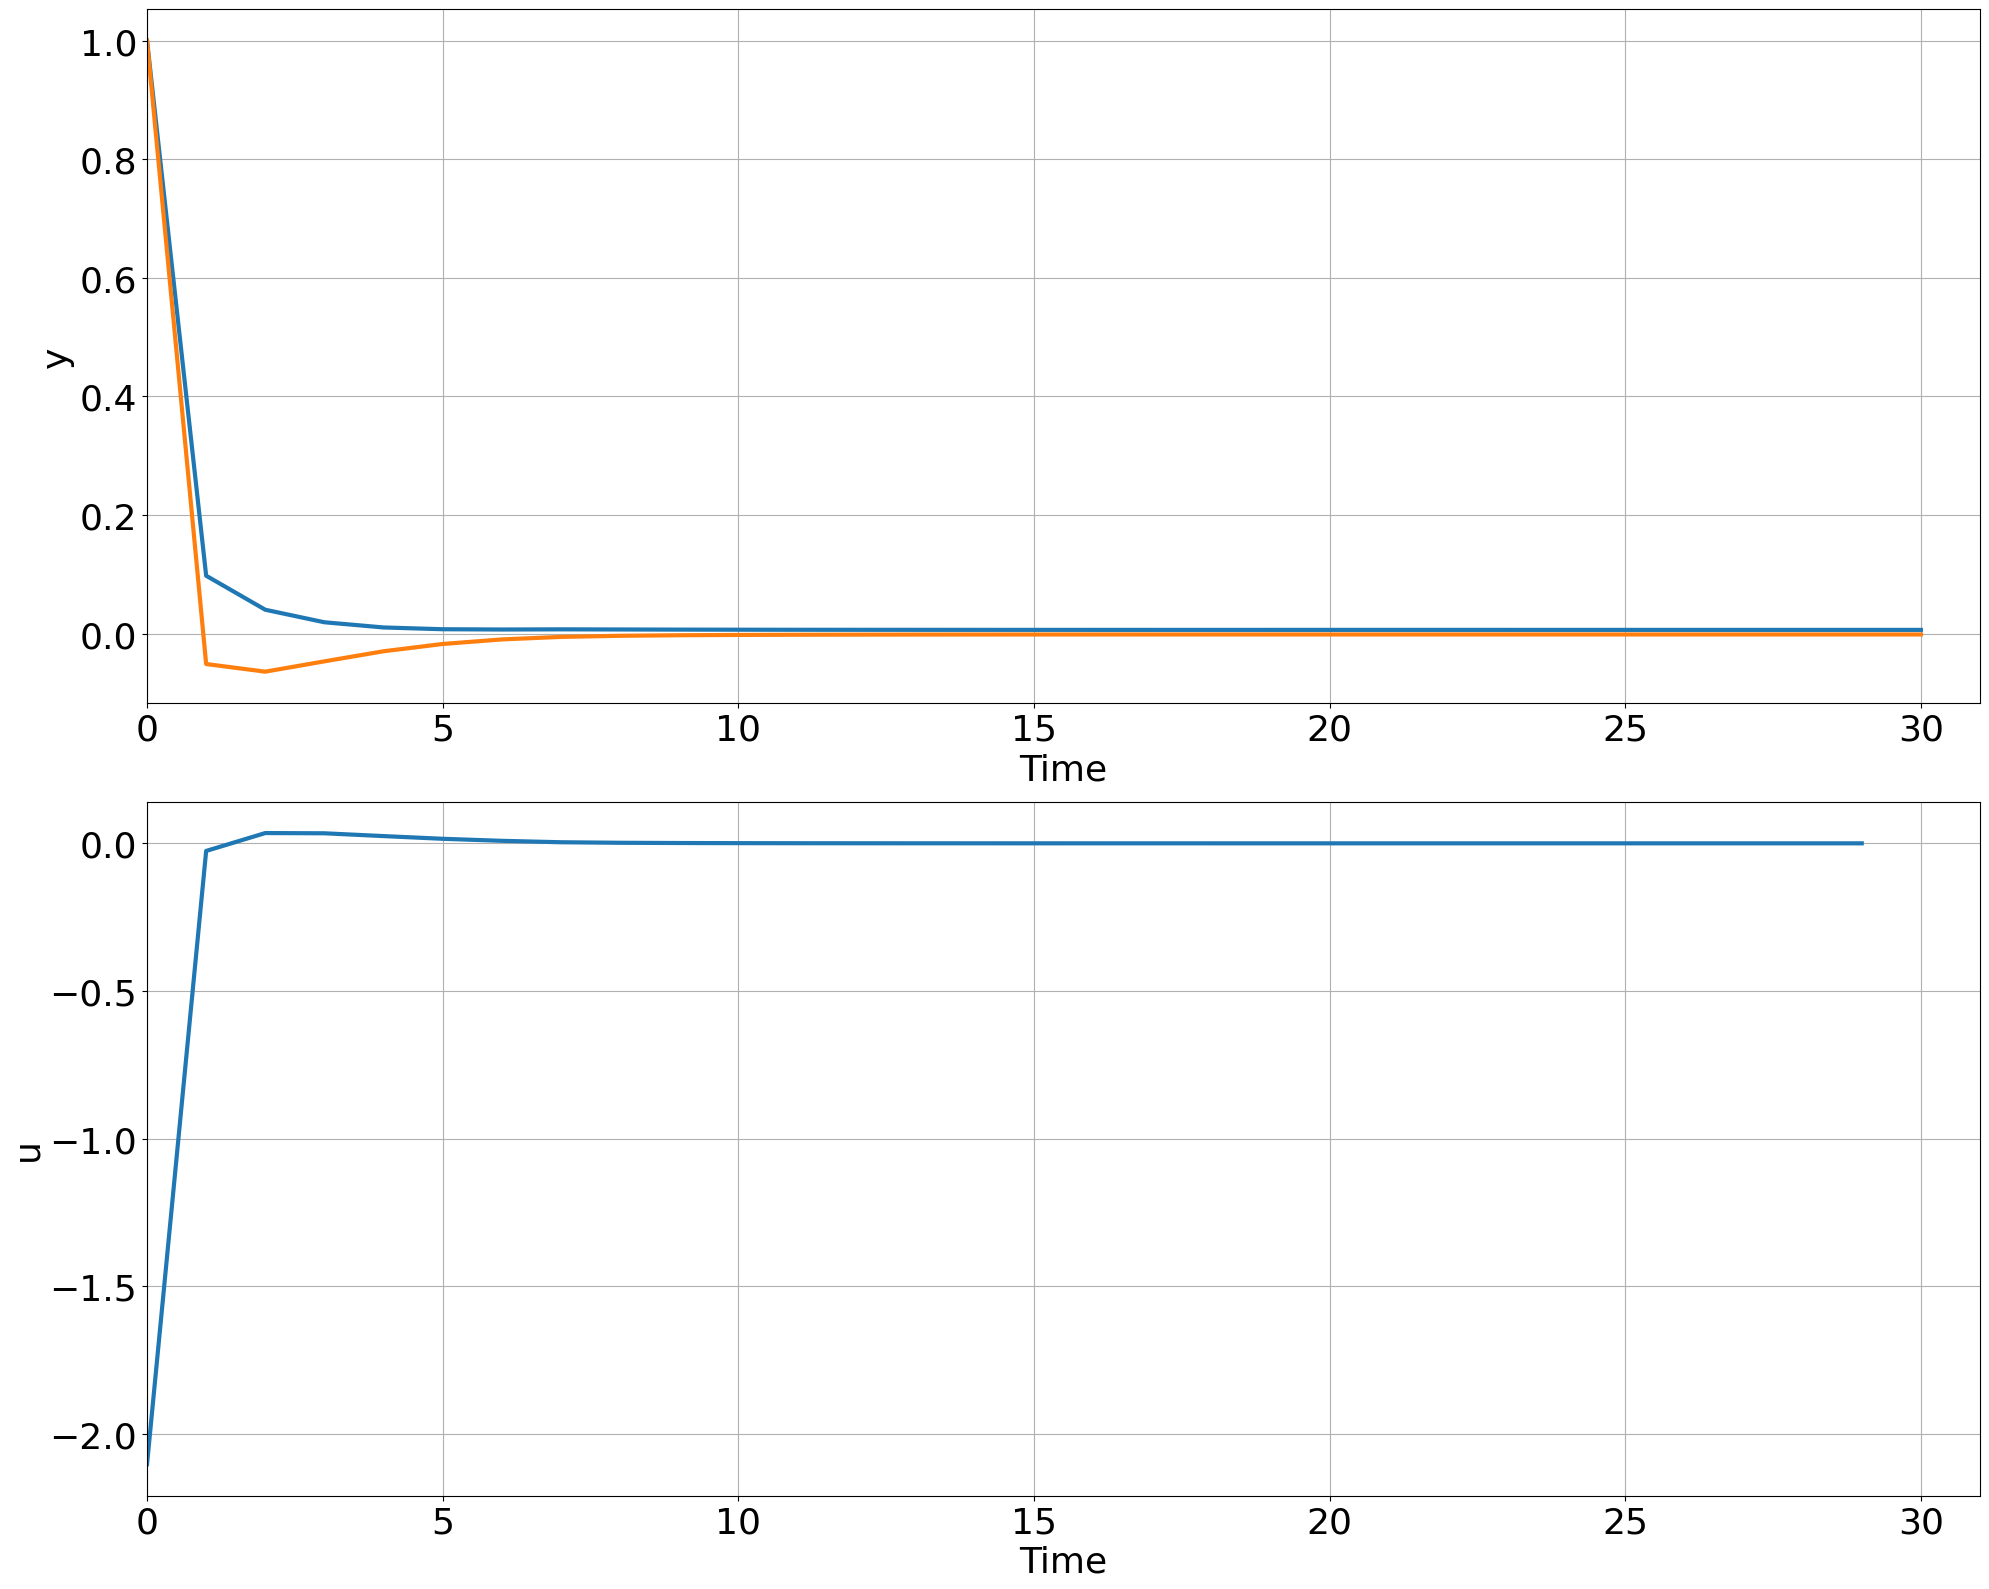

<Figure size 640x480 with 0 Axes>

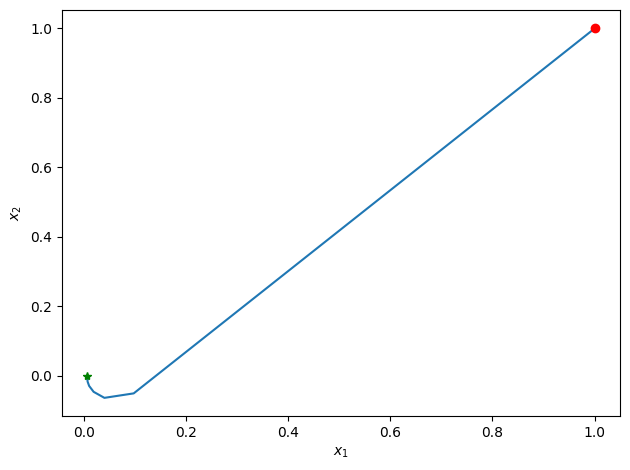

<Figure size 640x480 with 0 Axes>

In [19]:
# Test best model with prediction horizon of 50
problem_reg_cl.load_state_dict(best_model_reg_cl)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system_reg_cl.nsteps = nsteps
trajectories = cl_system_reg_cl(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')


## Observation
1. All of the three controllers manage to stabilize the system.
2. If we penalize the Jacobian of the controller or the Jacobian of the closed-loop dynamics, there are less acute / sharp change in the input given by the controller. Also, the corresponding trajectories become smoother.
3. Comparing two different way of regularization, we observe that regularizing on the closed-loop dynamics pushes towards the equilibrium faster than regularizing on the neural controller only while achieving similar smoothness in both trajectory and control input.
   
The enhanced smoothness in control input and the trajectory is desirable for controller design.

# Robustness Testing
Now we estimate the Lipschitz constant of all the three neural controllers u=NN(x).

In [20]:
import torch
import re

def extract_eclipse_tensors(model_dict, device='cpu'):
    """
    Extracts weights from a Neuromancer state_dict as a list of Double-Precision Tensors
    suitable for eclipse-nn input.
    
    Args:
        model_dict (dict): The state_dict from best_model (e.g., best_model_reg)
        device (str): 'cpu' or 'cuda'.
    
    Returns:
        weights (list of torch.Tensor): [W1, W2, ..., Wn] in float64
    """
    layer_weights = {}
    
    # Regex to capture layer index from keys like 'nodes.0...linear.0.weight'
    pattern = re.compile(r"linear\.(\d+)\.(weight)")
    
    for key, val in model_dict.items():
        match = pattern.search(key)
        if match:
            layer_idx = int(match.group(1))
            
            # CRITICAL FIX: Add .double() to match eclipse-nn's float64 requirement
            w_tensor = val.detach().clone().double().to(device)
            
            layer_weights[layer_idx] = w_tensor

    # Sort keys to ensure order: Layer 0 -> Layer 1 -> ...
    sorted_indices = sorted(layer_weights.keys())
    
    weights_list = [layer_weights[i] for i in sorted_indices]
    
    print(f"Extracted {len(weights_list)} weight matrices (float64).")
    return weights_list

In [21]:
# extract weights for Lipschitz estimates
Ws = extract_eclipse_tensors(best_model, device='cpu')
est = LipConstEstimator(weights=Ws)
# est.model_review()
lip = est.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller from standard training is {lip}")

Extracted 5 weight matrices (float64).
The Lipschitz estimate for controller from standard training is 3.5701943197528556


In [22]:
# extract weights for Lipschitz estimates
Ws_reg = extract_eclipse_tensors(best_model_reg, device='cpu')
est_reg = LipConstEstimator(weights=Ws_reg)
lip_reg = est_reg.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is {lip_reg}")

Extracted 5 weight matrices (float64).
The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is 2.8648636024378002


In [23]:
Ws_reg_cl = extract_eclipse_tensors(best_model_reg_cl, device='cpu')
est_reg_cl = LipConstEstimator(weights=Ws_reg_cl)
lip_reg_cl = est_reg_cl.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is {lip_reg_cl}")

Extracted 5 weight matrices (float64).
The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is 3.463208480035932


## Observation
The Lipschitz estimates of controllers trained with regularization on the Jacobian of the controller and the Jacobian of the closed-loop dynamics are smaller than the one from standard training, aligning with the enhanced smoothness in control input. The Lipschitz estimates of the controller trained with regularization on the Jacobian of the closed-loop dynamics is not that small. But it is possible that with the closed-loop, the Lipschitz constant is the best among all.